# Assignment 2

## Q1a. 
Write a python script (sim_mutations.py) to read in a fasta file, introduce a specified level of mutations, and then output a new fasta file. The input (-i) and output (-o) filenames should be set on the command line as should the level of mutations (-m) and the random seed (-s). For mutations, only introduce substitutions by changing the input base to a different base at random. The substitutions should be inserted at random locations at the specified rate. For example "-m 0.015" should change 1.5% of the original bases.

## Q1b. 
Now run the script using error rates 0.01, 0.05, 0.10 and 0.15 using three random seeds(e.g. 1, 2, 3), and compare the simulated mutation rate to the average identity (%IDY) computed by mummer. You may find this bash code helpful to evaluate all the runs. Note, with a mutation rate of 0.15 we expect the average identity to by 85%. Some deviation is expected because of rounding, plus mummer may choose to not extend an alignment to the very end of a sequence if there is a cluster of mutations

```bash
for rate in 0.01 0.05 0.10 0.15
do
    for seed in 1 2 3
    do
        if [ ! -r chr22_mut${rate}_s${seed}.fa ]
        then
            # introduce mutations
            python3 sim_mutations.py -i chr22_orig.fa -o chr22_mut${rate}_s${seed}.fa -m ${rate} -s ${seed}
            nucmer --mum -g 1000 -b 1000 -p chr22_orig_vs_mut${rate}_s${seed} chr22_orig.fa chr22_mut${rate}_s${seed}.fa
            delta-filter -1 chr22_orig_vs_mut${rate}_s${seed}.delta > chr22_orig_vs_mut${rate}_s${seed}.1delta
            show-coords -rcl chr22_orig_vs_mut${rate}_s${seed}.1delta > chr22_orig_vs_mut${rate}_s${seed}.coords
        fi
    done
done

head chr22_orig_vs_mut*.coords
```

##### OUTPUT
```
==> chr22_orig_vs_mut0.01_s1.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.01_s1.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    99.00  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.01_s2.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.01_s2.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    99.00  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.01_s3.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.01_s3.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    99.00  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.05_s1.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.05_s1.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    95.00  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.05_s2.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.05_s2.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    95.00  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.05_s3.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.05_s3.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    95.00  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.10_s1.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.10_s1.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    90.02  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.10_s2.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.10_s2.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1   999996  |        1   999996  |   999996   999996  |    90.02  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.10_s3.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.10_s3.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1   999973  |        1   999973  |   999973   999973  |    90.02  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.15_s1.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.15_s1.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1  1000001  |        1  1000001  |  1000001  1000001  |    85.09  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.15_s2.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.15_s2.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1   999996  |        1   999996  |   999996   999996  |    85.09  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000

==> chr22_orig_vs_mut0.15_s3.coords <==
/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_orig.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/chr22_mut0.15_s3.fa
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  |  [LEN R]  [LEN Q]  |  [COV R]  [COV Q]  | [TAGS]
===============================================================================================================================
       1   999973  |        1   999973  |   999973   999973  |    85.09  |  1000001  1000001  |   100.00   100.00  | chr22:20000000-21000000    chr22:20000000-21000000
```

## Q1c.
Now write a python program to compute the Jaccard coefficient between two sequences specified with -a and -b using the specified kmer length (-k) Output the Jaccard coeffient, the ANI (computed by computing the kth root), and the approximate ANI computed using natural log. Convert any lowercase letters to uppercase, and convert any non-ACGT characters to N.

## Q1d. 
Run your Jaccard coefficient program on all the simulated sequences. Output a table of filename, expected identity, jaccard, exact ANI, and approximate ANI. Comment on how well the ANI and approximate ANI compares to the expected level of mutation. You may find this bash code helpful to run everything.

```bash
for rate in 0.01 0.05 0.10 0.15
do
    for seed in 1 2 3
    do
        if [ ! -r jaccard_mut${rate}_s${seed}.txt ]
        then
            python compute_jaccard.py -a chr22_orig.fa -b chr22_mut${rate}_s${seed}.fa -k 21 > jaccard_mut${rate}_s${seed}.txt
        fi
    done
done

head jaccard_mut*.txt
```


##### OUTPUT
```
==> jaccard_mut0.01_s1.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 943397
|A ∩ B|   = 756301
|A ∪ B|   = 1116081
Jaccard  = 0.677640
ANI (kth-root) = 0.981640
ANI (ln approx) = 0.981640

==> jaccard_mut0.01_s2.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 943325
|A ∩ B|   = 755751
|A ∪ B|   = 1116559
Jaccard  = 0.676857
ANI (kth-root) = 0.981586
ANI (ln approx) = 0.981586

==> jaccard_mut0.01_s3.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 943987
|A ∩ B|   = 756407
|A ∪ B|   = 1116565
Jaccard  = 0.677441
ANI (kth-root) = 0.981626
ANI (ln approx) = 0.981626

==> jaccard_mut0.05_s1.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 977984
|A ∩ B|   = 328403
|A ∪ B|   = 1578566
Jaccard  = 0.208039
ANI (kth-root) = 0.927963
ANI (ln approx) = 0.927963

==> jaccard_mut0.05_s2.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 978156
|A ∩ B|   = 326263
|A ∪ B|   = 1580878
Jaccard  = 0.206381
ANI (kth-root) = 0.927610
ANI (ln approx) = 0.927610

==> jaccard_mut0.05_s3.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 977559
|A ∩ B|   = 325915
|A ∪ B|   = 1580629
Jaccard  = 0.206193
ANI (kth-root) = 0.927569
ANI (ln approx) = 0.927569

==> jaccard_mut0.10_s1.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 998893
|A ∩ B|   = 34873
|A ∪ B|   = 1893005
Jaccard  = 0.018422
ANI (kth-root) = 0.826793
ANI (ln approx) = 0.826793

==> jaccard_mut0.15_s2.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 999036
|A ∩ B|   = 34483
|A ∪ B|   = 1893538
Jaccard  = 0.018211
ANI (kth-root) = 0.826340
ANI (ln approx) = 0.826340

==> jaccard_mut0.15_s3.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 999039
|A ∩ B|   = 34732
|A ∪ B|   = 1893292
Jaccard  = 0.018345
ANI (kth-root) = 0.826628
ANI (ln approx) = 0.826628
(asn2) suki@suki-2 assignment2 % for rate in 0.01 0.05 0.10 0.15
do
    for seed in 1 2 3
    do
        if [ ! -r jaccard_mut${rate}_s${seed}.txt ]
        then
            python compute_jaccard.py -a chr22_orig.fa -b chr22_mut${rate}_s${seed}.fa -k 21 > jaccard_mut${rate}_s${seed}.txt
        fi
    done
done

head jaccard_mut*.txt
==> jaccard_mut0.01_s1.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 943397
|A ∩ B|   = 756301
|A ∪ B|   = 1116081
Jaccard  = 0.677640
ANI (kth-root) = 0.981640
ANI (ln approx) = 0.981640

==> jaccard_mut0.01_s2.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 943325
|A ∩ B|   = 755751
|A ∪ B|   = 1116559
Jaccard  = 0.676857
ANI (kth-root) = 0.981586
ANI (ln approx) = 0.981586

==> jaccard_mut0.01_s3.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 943987
|A ∩ B|   = 756407
|A ∪ B|   = 1116565
Jaccard  = 0.677441
ANI (kth-root) = 0.981626
ANI (ln approx) = 0.981626

==> jaccard_mut0.05_s1.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 977984
|A ∩ B|   = 328403
|A ∪ B|   = 1578566
Jaccard  = 0.208039
ANI (kth-root) = 0.927963
ANI (ln approx) = 0.927963

==> jaccard_mut0.05_s2.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 978156
|A ∩ B|   = 326263
|A ∪ B|   = 1580878
Jaccard  = 0.206381
ANI (kth-root) = 0.927610
ANI (ln approx) = 0.927610

==> jaccard_mut0.05_s3.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 977559
|A ∩ B|   = 325915
|A ∪ B|   = 1580629
Jaccard  = 0.206193
ANI (kth-root) = 0.927569
ANI (ln approx) = 0.927569

==> jaccard_mut0.1_s1.txt <==

==> jaccard_mut0.1_s2.txt <==

==> jaccard_mut0.1_s3.txt <==

==> jaccard_mut0.10_s1.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 994654
|A ∩ B|   = 111748
|A ∪ B|   = 1811891
Jaccard  = 0.061675
ANI (kth-root) = 0.875762
ANI (ln approx) = 0.875762

==> jaccard_mut0.10_s2.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 994716
|A ∩ B|   = 109402
|A ∪ B|   = 1814299
Jaccard  = 0.060300
ANI (kth-root) = 0.874822
ANI (ln approx) = 0.874822

==> jaccard_mut0.10_s3.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 994505
|A ∩ B|   = 109870
|A ∪ B|   = 1813620
Jaccard  = 0.060580
ANI (kth-root) = 0.875016
ANI (ln approx) = 0.875016

==> jaccard_mut0.15_s1.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 998893
|A ∩ B|   = 34873
|A ∪ B|   = 1893005
Jaccard  = 0.018422
ANI (kth-root) = 0.826793
ANI (ln approx) = 0.826793

==> jaccard_mut0.15_s2.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 999036
|A ∩ B|   = 34483
|A ∪ B|   = 1893538
Jaccard  = 0.018211
ANI (kth-root) = 0.826340
ANI (ln approx) = 0.826340

==> jaccard_mut0.15_s3.txt <==
K=21
|A k-mers| = 928985
|B k-mers| = 999039
|A ∩ B|   = 34732
|A ∪ B|   = 1893292
Jaccard  = 0.018345
ANI (kth-root) = 0.826628
ANI (ln approx) = 0.826628
```

## Q1e. 
Recall that modimizers are the subset of kmers such that hash(kmer) % m == 0. Implement compute_jaccard_modimizer.py that extends your existing compute_jaccard.py code to only store and evaluate the modimizers in the sequences. The level of sampling should be set with the -m parameter. Also output the number of modimizers found in each sequence. Note the default hash function in python is salted (it changes with every run), so instead use a stable function with zlib32 crc: hash = zlib.crc32(kmer.encode('utf-8')) & 0xffffffff

## Q1f. 
Now run your compute_jaccard_modimizers.py program using m=100 and m=1000 to output the jaccard, exact ANI, approximate ANI, and the number of modimizers found in each sequence. Comment on how well the modimizers approximate ANI values as found in Q1d as well as the amount of space needed to reach this level.

```bash
for rate in 0.01 0.05 0.10 0.15
do
    for seed in 1 2 3
    do
        for mod in 100 1000
        do
            if [ ! -r modimizers_mut${rate}_s${seed}_m${mod}.txt ]
            then
                python compute_jaccard_modimizer.py -a chr22_orig.fa -b chr22_mut${rate}_s${seed}.fa -k 21 -m $mod > modimizers_mut${rate}_s${seed}_m${mod}.txt
            fi
        done
    done
done

head -100 modimizers_mut*.txt
```

### OUTPUT
```
==> modimizers_mut0.01_s1_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9521
|A ∩ B|   = 7581
|A ∪ B|   = 11230
Jaccard  = 0.675067
ANI (kth-root) = 0.981462
ANI (ln approx) = 0.981462

==> modimizers_mut0.01_s1_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 957
|A ∩ B|   = 761
|A ∪ B|   = 1127
Jaccard  = 0.675244
ANI (kth-root) = 0.981475
ANI (ln approx) = 0.981475

==> modimizers_mut0.01_s2_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9464
|A ∩ B|   = 7606
|A ∪ B|   = 11148
Jaccard  = 0.682275
ANI (kth-root) = 0.981959
ANI (ln approx) = 0.981959

==> modimizers_mut0.01_s2_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 933
|A ∩ B|   = 747
|A ∪ B|   = 1117
Jaccard  = 0.668756
ANI (kth-root) = 0.981023
ANI (ln approx) = 0.981023

==> modimizers_mut0.01_s3_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9384
|A ∩ B|   = 7558
|A ∪ B|   = 11116
Jaccard  = 0.679921
ANI (kth-root) = 0.981797
ANI (ln approx) = 0.981797

==> modimizers_mut0.01_s3_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 970
|A ∩ B|   = 773
|A ∪ B|   = 1128
Jaccard  = 0.685284
ANI (kth-root) = 0.982165
ANI (ln approx) = 0.982165

==> modimizers_mut0.05_s1_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9775
|A ∩ B|   = 3300
|A ∪ B|   = 15765
Jaccard  = 0.209324
ANI (kth-root) = 0.928235
ANI (ln approx) = 0.928235

==> modimizers_mut0.05_s1_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 922
|A ∩ B|   = 324
|A ∪ B|   = 1529
Jaccard  = 0.211903
ANI (kth-root) = 0.928777
ANI (ln approx) = 0.928777

==> modimizers_mut0.05_s2_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9912
|A ∩ B|   = 3368
|A ∪ B|   = 15834
Jaccard  = 0.212707
ANI (kth-root) = 0.928944
ANI (ln approx) = 0.928944

==> modimizers_mut0.05_s2_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 1052
|A ∩ B|   = 341
|A ∪ B|   = 1642
Jaccard  = 0.207674
ANI (kth-root) = 0.927885
ANI (ln approx) = 0.927885

==> modimizers_mut0.05_s3_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9839
|A ∩ B|   = 3228
|A ∪ B|   = 15901
Jaccard  = 0.203006
ANI (kth-root) = 0.926882
ANI (ln approx) = 0.926882

==> modimizers_mut0.05_s3_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 957
|A ∩ B|   = 327
|A ∪ B|   = 1561
Jaccard  = 0.209481
ANI (kth-root) = 0.928268
ANI (ln approx) = 0.928268

==> modimizers_mut0.10_s1_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9945
|A ∩ B|   = 1152
|A ∪ B|   = 18083
Jaccard  = 0.063706
ANI (kth-root) = 0.877114
ANI (ln approx) = 0.877114

==> modimizers_mut0.10_s1_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 1017
|A ∩ B|   = 121
|A ∪ B|   = 1827
Jaccard  = 0.066229
ANI (kth-root) = 0.878738
ANI (ln approx) = 0.878738

==> modimizers_mut0.10_s2_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9922
|A ∩ B|   = 1119
|A ∪ B|   = 18093
Jaccard  = 0.061847
ANI (kth-root) = 0.875878
ANI (ln approx) = 0.875878

==> modimizers_mut0.10_s2_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 1009
|A ∩ B|   = 125
|A ∪ B|   = 1815
Jaccard  = 0.068871
ANI (kth-root) = 0.880376
ANI (ln approx) = 0.880376

==> modimizers_mut0.10_s3_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9927
|A ∩ B|   = 1140
|A ∪ B|   = 18077
Jaccard  = 0.063064
ANI (kth-root) = 0.876691
ANI (ln approx) = 0.876691

==> modimizers_mut0.10_s3_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 984
|A ∩ B|   = 103
|A ∪ B|   = 1812
Jaccard  = 0.056843
ANI (kth-root) = 0.872367
ANI (ln approx) = 0.872367

==> modimizers_mut0.15_s1_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9948
|A ∩ B|   = 381
|A ∪ B|   = 18857
Jaccard  = 0.020205
ANI (kth-root) = 0.830438
ANI (ln approx) = 0.830438

==> modimizers_mut0.15_s1_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 977
|A ∩ B|   = 35
|A ∪ B|   = 1873
Jaccard  = 0.018687
ANI (kth-root) = 0.827355
ANI (ln approx) = 0.827355

==> modimizers_mut0.15_s2_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9916
|A ∩ B|   = 343
|A ∪ B|   = 18863
Jaccard  = 0.018184
ANI (kth-root) = 0.826281
ANI (ln approx) = 0.826281

==> modimizers_mut0.15_s2_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 1033
|A ∩ B|   = 51
|A ∪ B|   = 1913
Jaccard  = 0.026660
ANI (kth-root) = 0.841474
ANI (ln approx) = 0.841474

==> modimizers_mut0.15_s3_m100.txt <==
K=21, M=100
|A modimizers| = 9290
|B modimizers| = 9971
|A ∩ B|   = 354
|A ∪ B|   = 18907
Jaccard  = 0.018723
ANI (kth-root) = 0.827432
ANI (ln approx) = 0.827432

==> modimizers_mut0.15_s3_m1000.txt <==
K=21, M=1000
|A modimizers| = 931
|B modimizers| = 1040
|A ∩ B|   = 31
|A ∪ B|   = 1940
Jaccard  = 0.015979
ANI (kth-root) = 0.821212
ANI (ln approx) = 0.821212
```

# Question 2. de Bruijn Graph construction [10 pts]
## Q2a. 
Write a script (in python, R, C++, etc) to draw the de Bruijn graph for the following reads using k=3 (assume all reads are from the forward strand, no sequencing errors, complete coverage of the genome). You may find graphviz to be helpful (see below).
```
  ATTCA
  ATTGA
  CATTG
  CTTAT
  GATTG
  TATTT
  TCATT
  TCTTA
  TGATT
  TTATT
  TTCAT
  TTCTT
  TTGAT
```

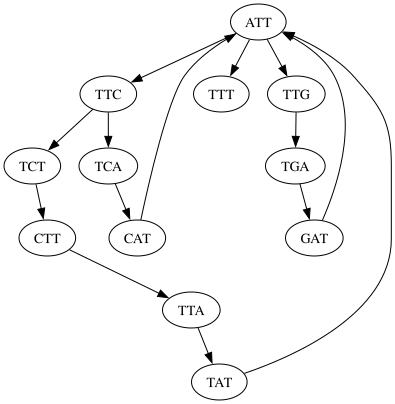

In [8]:
# %mamba install graphviz

from graphviz import Digraph

reads = [
    "ATTCA",
    "ATTGA",
    "CATTG",
    "CTTAT",
    "GATTG",
    "TATTT",
    "TCATT",
    "TCTTA",
    "TGATT",
    "TTATT",
    "TTCAT",
    "TTCTT",
    "TTGAT",
]
k = 3  # generate 3-mers

edges = set()
nodes = set()

# build nodes as k-mers and edges between consecutive k-mers (overlap k-1)
for read in reads:
    for i in range(len(read) - k):
        kmer1 = read[i : i + k]
        kmer2 = read[i + 1 : i + 1 + k]
        nodes.add(kmer1)
        nodes.add(kmer2)
        edges.add((kmer1, kmer2))

dot = Digraph(comment="De Bruijn Graph (k=3)", format="png")
for node in sorted(nodes):
    dot.node(node)
for src, dst in sorted(edges):
    dot.edge(src, dst)

dot.render("debruijn_graph_k3", view=False)  # Saves as debruijn_graph_k3.png

# Display in notebook
dot

## Q2b. 
Assume that the maximum number of occurrences of any 3-mer in the actual genome is 4 using the k-mers from Q1a. Write one possible genome sequence. Note this genome sequence may include sequences that are not supported by the underlying reads (this is the well known read decoherency problem for genome assembly).




In [15]:
# print all the k-mers and their counts
from collections import Counter

sequence = "ATTGATTCATTCTTATT"
k = 3
kmers = [sequence[i:i+k] for i in range(len(sequence)-k+1)]
kmer_counts = Counter(kmers)

for kmer, count in kmer_counts.items():
    print(f"{kmer}: {count}")

ATT: 4
TTG: 1
TGA: 1
GAT: 1
TTC: 2
TCA: 1
CAT: 1
TCT: 1
CTT: 1
TTA: 1
TAT: 1


## Q2c.
What would it take to fully resolve the genome? [In a few sentences]

*At the sequencing level, we would need to obtain longer reads to span repetitive regions and resolve circles in the de Bruijn graph. To determine the exact length required, we would need to analyze the distribution of repeats and ensure that the reads are long enough to cover them. Additionally, increasing the coverage depth would help to ensure that all regions of the genome are adequately represented in the reads, reducing gaps and ambiguities in the assembly. To determine the required coverage, we could use simulations to model the expected read distribution at different coverage levels for each region and ensure that we have enough data to accurately reconstruct the genome.
At the assembly level, we would need count information for each k-mer to determine the correct number of times each k-mer should appear in the genome. In that way, we can determine the correct path with the correct number of repetitions for each k-mer, thus fully resolving the genome. Also, increasing the k-mer size could help to reduce the number of possible paths in the de Bruijn graph, making it easier to resolve the genome.*

## Q3. Kmer Analysis [20 pts]
Use `jellyfish` to count the 21-mers in the reads data (all reads should be counted together). Make sure to use the "-C" flag to count cannonical kmers, otherwise your analysis will not correctly account for the fact that your reads come from either strand of DNA.

## Question 3a. 
How many kmers occur exactly 50 times? [Hint: try jellyfish histo]

In [25]:
# echo the 50th line of reads.histo
!sed -n '50p' reads.histo

50 932


## Question 3b. 
What are the top 10 most frequently occurring kmers [Hint: try jellyfish dump along with sort and head]

In [28]:
!jellyfish dump -c mer_counts.jf | sort -k2,2nr | head -n 10

AGGTTCAATTCCTGCCGGGCG 93
CGCGCCCGGCAGGAATTGAAC 91
GCGCCCGGCAGGAATTGAACC 91
CAGGTTCAATTCCTGCCGGGC 90
CCCGGCAGGAATTGAACCTGC 90
CCGGCAGGAATTGAACCTGCG 90
GAAGGTCGCAGGTTCAATTCC 90
GCAGGAATTGAACCTGCGACC 90
GCGCGCCCGGCAGGAATTGAA 90
GGCGCGCCCGGCAGGAATTGA 90
sort: Broken pipe


## Question 3c. 
What is the estimated genome size based on the kmer frequencies? [Hint: upload the jellyfish histogram to GenomeScope2 and report the min "Genome Haploid Length" in the "Results" section]

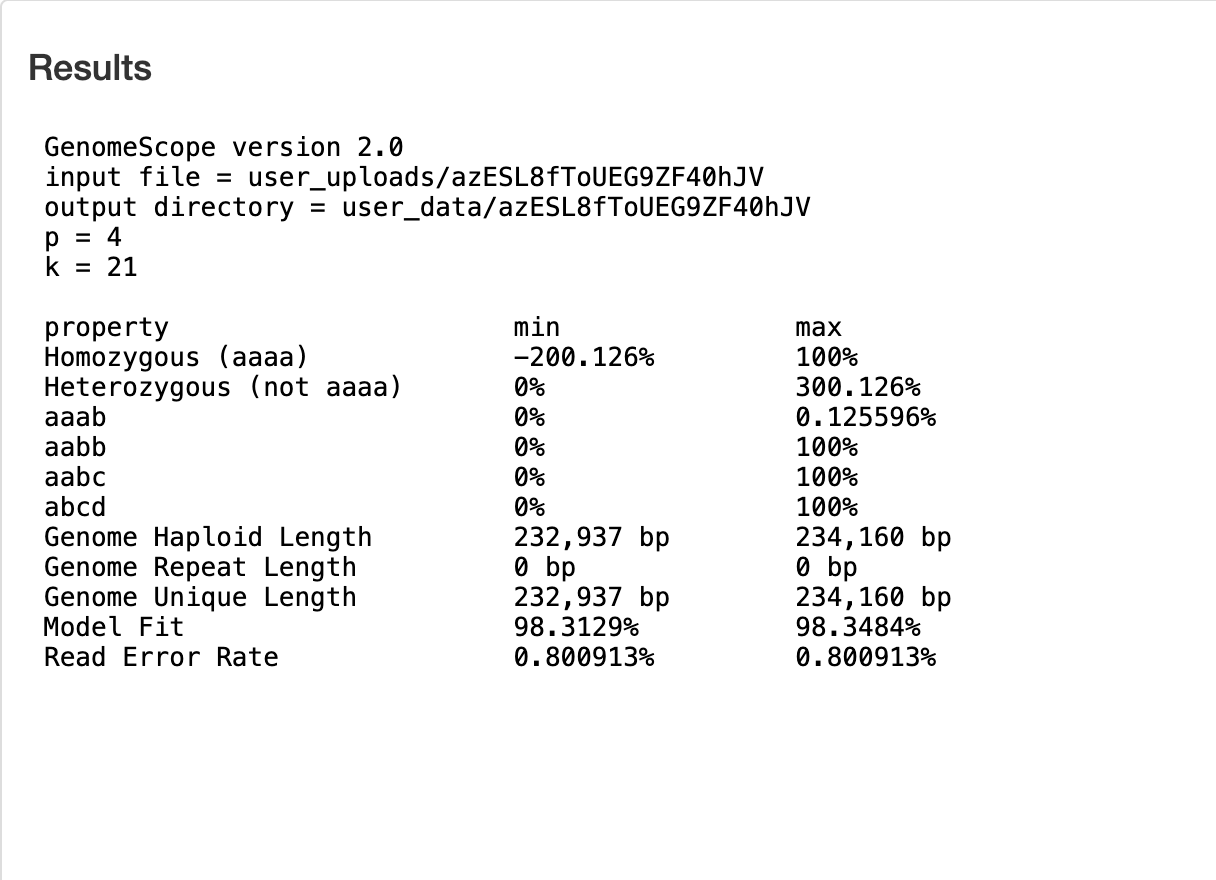

In [31]:
from IPython.display import Image, display
import os

fname = "GenomeScopeResults.png"
if os.path.exists(fname):
    display(Image(filename=fname))
else:
    print(f"{fname} not found in current directory: {os.getcwd()}")

*Min Genome Haploid Length : 232,937 bp*

## Question 3d. 
How well does the GenomeScope genome size estimate compare to the reference genome? [Hint: In a sentence or two]

In [39]:
# calculate the true size from the reference genome
!grep -v ">" asm/ref.fa | wc -c

  237147


In [41]:
# Compare the GenomeScope genome size estimate to the reference genome
# Min Genome Haploid Length : 
232_937/237_147

0.9822472980893707

Given the results from GenomeScope, the estimated genome size is approximately 232,937 bp. When compared to the reference genome size of 237,147 bp, the estimate is slightly lower. But it's 0.982 % close to the reference genome size, indicating that the k-mer based estimation is reasonably accurate. The small discrepancy could be due to factors such as sequencing errors, repetitive regions, or incomplete coverage in the reads used for k-mer counting. Overall, the estimate provides a good approximation of the actual genome size.

# Question 4. De novo assembly [20 pts]
Assemble the reads using spades. Spades will not run on Windows, you must use a linux/mac environment (The Ubuntu subsystem might work?). The assembly should complete in <1 minute.

Note: N50 size is the size such that half of the total amount of bases are in contigs this size or larger (a weighted median). For example, if you have contig sizes of 10kbp, 5kb, 3kbp, 1kbp, 1kbp, 1kbp. The total size is 21kbp. Half of this value is 10.5kbp, so the N50 size is 5kbp. To compute the N50 value, sort the contigs from largest to small, and then iterative through until their cummulative span reaches 50% of the total span.



In [42]:
!spades.py --isolate --pe1-1 asm/frag180.1.fq --pe1-2 asm/frag180.2.fq --mp1-1 asm/jump2k.1.fq --mp1-2 asm/jump2k.2.fq -o asm -t 4 -k 31



== Warning ==  output dir is not empty! Please, clean output directory before run.


Command line: /Users/suki/miniforge3/envs/asn2/bin/spades.py	--isolate	--pe1-1	/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/frag180.1.fq	--pe1-2	/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/frag180.2.fq	--mp1-1	/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/jump2k.1.fq	--mp1-2	/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/jump2k.2.fq	-o	/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm	-t	4	-k	31	

System information:
  SPAdes version: 4.2.0
  Python version: 3.10.18
  OS: macOS-15.6.1-arm64-arm-64bit

Output dir: /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm
Mode: ONLY assembling (without read error correction)
Debug mode is turned OFF

Dataset parameters:
  Isolate mode
  Reads:
    Library number: 1, library type: paired-end
      orientation: fr
      left reads: 

## Question 4a. 
How many contigs were produced? [Hint: try grep -c '>' contigs.fasta]

In [43]:
!grep -c '>' asm/contigs.fasta

4


## Question 4b. 
What is the total length of the contigs? [Hint: try samtools faidx, plus a short script/excel]


In [50]:
# calculate the total length of the contigs
!samtools faidx asm/K31/final_contigs.fasta
# The contigs.fasta.fai file has the format:
# contig_name \t contig_length \t offset \t line_bases \t line_width
!cat asm/K31/final_contigs.fasta.fai
# total length of contigs
total = 0
with open("asm/K31/final_contigs.fasta.fai") as f:
    for line in f:
        fields = line.strip().split('\t')
        length = int(fields[1])
        total += length
print(f"Total contig size: {total}")

NODE_1_length_105834_cov_18.177840	105834	36	60	61
NODE_2_length_47849_cov_17.929943	47849	107669	60	61
NODE_3_length_41445_cov_18.207587	41445	156351	60	61
NODE_4_length_39441_cov_18.559959	39441	198522	60	61
Total contig size: 234569


## Question 4c. 
What is the size of your large contig? [Hint: check samtools faidx plus sort -n]


In [51]:
# sort the contigs.fasta.fai by contig length (2nd column) and get the largest contig size
!sort -k2,2nr asm/K31/final_contigs.fasta.fai | head -n 1

NODE_1_length_105834_cov_18.177840	105834	36	60	61


## Question 4d. 
What is the contig N50 size? [Hint: Write a short script, or use excel]

In [53]:
# N50 size is the size such that half of the total amount of bases are in contigs 
# this size or larger (a weighted median). For example, if you have contig sizes 
# of 10kbp, 5kb, 3kbp, 1kbp, 1kbp, 1kbp. The total size is 21kbp. Half of this 
# value is 10.5kbp, so the N50 size is 5kbp. To compute the N50 value, sort the 
# contigs from largest to small, and then iterative through until their cummulative 
# span reaches 50% of the total span.

contig_lengths = []
with open("asm/K31/final_contigs.fasta.fai") as f:
    for line in f:
        fields = line.strip().split('\t')
        length = int(fields[1])
        contig_lengths.append(length)
contig_lengths.sort(reverse=True)
cumulative_length = 0
half_total_length = total / 2
n50 = 0
for length in contig_lengths:
    cumulative_length += length
    if cumulative_length >= half_total_length:
        n50 = length
        break
print(f"N50 size: {n50}")

N50 size: 47849


# Question 5. Finding and decoding the insertion [20 pts]
Use the `mummer` software tools to align your contigs to the reference genome. This will reveal all of the structural variants present, including the secret insertion.



## Question 5a. 
How many insertions and deletions are in the assembly? [Hint: try dnadiff]


In [ ]:
!nucmer asm/ref.fa asm/contigs.fasta
!dnadiff asm/ref.fa asm/contigs.fasta

1: PREPARING DATA
2,3: RUNNING mummer AND CREATING CLUSTERS
# reading input file "out.ntref" of length 233807
# construct suffix tree for sequence of length 233807
# (maximum reference length is 2305843009213693948)
# (maximum query length is 18446744073709551615)
# process 2338 characters per dot
#....................................................................................................
# CONSTRUCTIONTIME /Users/suki/miniforge3/envs/asn2/opt/mummer-3.23/mummer out.ntref 0.02
# reading input file "/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/contigs.fasta" of length 234572
# matching query-file "/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/contigs.fasta"
# against subject-file "out.ntref"
# COMPLETETIME /Users/suki/miniforge3/envs/asn2/opt/mummer-3.23/mummer out.ntref 0.05
# SPACE /Users/suki/miniforge3/envs/asn2/opt/mummer-3.23/mummer out.ntref 0.45
4: FINISHING DATA
Building alignments
1: PREPARING DATA
2,3: RUNNING mummer AND

In [80]:
!cat out.report | grep -i Insertion
!cat out.report | grep -i Deletion
!cat out.rdiff
!cat out.qdiff

Insertions                         5                    1
InsertionSum                      45                  808
InsertionAvg                    9.00               808.00
Halomonas	BRK	1	2	2
Halomonas	GAP	26790	26787	-2	806	-808
Halomonas	SEQ	40640	40663	24	NODE_3_length_41445_cov_18.207587	NODE_2_length_47849_cov_17.929943
Halomonas	SEQ	88513	88515	3	NODE_2_length_47849_cov_17.929943	NODE_4_length_39441_cov_18.559959
Halomonas	SEQ	127957	127959	3	NODE_4_length_39441_cov_18.559959	NODE_1_length_105834_cov_18.177840
Halomonas	BRK	233794	233806	13
NODE_3_length_41445_cov_18.207587	GAP	13853	14658	806	-2	808


From the output file, 
Insertions: 5 (reference), 1 (assembly)
Deletions: 0

## Question 5b. 
What is the position of the insertion on the reference? [Hint: try show-coords]



## Question 5c. 
How long is the novel insertion? [Hint: try show-coords]


In [74]:
!show-coords out.delta

/Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/ref.fa /Users/suki/Projects/appliedgenomics2025/assignments/assignment2/asm/contigs.fasta
NUCMER

    [S1]     [E1]  |     [S2]     [E2]  |  [LEN 1]  [LEN 2]  |  [% IDY]  | [TAGS]
  127960   233793  |   105834        1  |   105834   105834  |   100.00  | Halomonas	NODE_1_length_105834_cov_18.177840
   40664    88512  |    47849        1  |    47849    47849  |   100.00  | Halomonas	NODE_2_length_47849_cov_17.929943
       3    26789  |    41445    14659  |    26787    26787  |   100.00  | Halomonas	NODE_3_length_41445_cov_18.207587
   26788    40639  |    13852        1  |    13852    13852  |   100.00  | Halomonas	NODE_3_length_41445_cov_18.207587
   88516   127956  |    39441        1  |    39441    39441  |   100.00  | Halomonas	NODE_4_length_39441_cov_18.559959


In [82]:
# given the output from show-cords, find the insertion by looking for a gap in the reference

# extract the first and second columns (start and end in reference)
# run show-coords with formatting and extract reference start/end (first two numeric columns)
!show-coords out.delta | awk '$1 ~ /^[0-9]+$/ {print $1"\t"$2}' > ref_coords.txt
# read the coordinates into a list of tuples
ref_coords = []
with open("ref_coords.txt") as f:
    for line in f:
        fields = line.strip().split('\t')
        start = int(fields[0])
        end = int(fields[1])
        ref_coords.append((start, end))
# sort by start coordinate
ref_coords.sort()
# look for gaps between consecutive coordinates
gaps = []
for i in range(1, len(ref_coords)):
    prev_end = ref_coords[i-1][1]
    curr_start = ref_coords[i][0]
    if curr_start > prev_end + 1:
        gaps.append((prev_end + 1, curr_start - 1))
# print the gaps
for gap in gaps:
    print(f"Gap in reference from {gap[0]} to {gap[1]}, size {gap[1]-gap[0]+1}")

Gap in reference from 40640 to 40663, size 24
Gap in reference from 88513 to 88515, size 3
Gap in reference from 127957 to 127959, size 3


## Question 5d. 
What is the DNA sequence of the encoded message? [Hint: try samtools faidx to extract the insertion]

In [114]:
# save samtools faidx outputs to a single text file
!samtools faidx chr22_orig.fa chr22:40640-40663 #| grep -v '^>' > message1.txt
!samtools faidx chr22_orig.fa chr22:88513-88515 #| grep -v '^>' > message2.txt
!samtools faidx chr22_orig.fa chr22:127957-127959 #| grep -v '^>' > message3.txt
# !cat message1.txt message2.txt message3.txt > message.txt
# !cat message.txt

[W::fai_get_val] Reference chr22:40640-40663 not found in FASTA file, returning empty sequence
[W::fai_get_val] Reference chr22:40640-40663 not found in FASTA file, returning empty sequence
[faidx] Failed to fetch sequence in chr22:40640-40663
>chr22:40640-40663
[W::fai_get_val] Reference chr22:88513-88515 not found in FASTA file, returning empty sequence
[W::fai_get_val] Reference chr22:88513-88515 not found in FASTA file, returning empty sequence
[faidx] Failed to fetch sequence in chr22:88513-88515
>chr22:88513-88515
[W::fai_get_val] Reference chr22:127957-127959 not found in FASTA file, returning empty sequence
[W::fai_get_val] Reference chr22:127957-127959 not found in FASTA file, returning empty sequence
[faidx] Failed to fetch sequence in chr22:127957-127959
>chr22:127957-127959


In [103]:
# save samtools faidx outputs to a single text file
!samtools faidx chr22.fa chr22:40640-40663 | grep -v '^>' > message1.txt
!samtools faidx chr22.fa chr22:88513-88515 | grep -v '^>' > message2.txt
!samtools faidx chr22.fa chr22:127957-127959 | grep -v '^>' > message3.txt
!cat message1.txt message2.txt message3.txt > message.txt
!cat message.txt

NNNNNNNNNNNNNNNNNNNNNNNN
NNN
NNN


## Question 5e. 
What is the secret message? [Hint: run dna-decode.py -d --input message.fa to decode the string from 5c. If needed use the --rev_comp to reverse complement the sequence:]

In [113]:
# run dna-decode.py -d --input message.fa to decode the string from 5c. If needed use the --rev_comp to reverse complement the sequence:
# for each line in message.txt that does not start with '>', run dna-decode.py -d --input <line> --rev_comp
message_files = ["message1.txt", "message2.txt", "message3.txt"]
messages = []
for mf in message_files:
    !asm/dna-decode.py -e --input {mf} --rev_comp
    !asm/dna-decode.py -e --input {mf} 

# The encoded message :  GCCCGGATTAAAGTATTAAAGGCGTCCAGTCGTCCATTCTGCCATGAGGCCCGTATTCACTTATGAACTGAGTACATGATTCAATTCTGCCCGTAGTCCAGTAGTACATGAGGACCGTCGTCAAGGAGTACCTGCTTACCTGAGTCCATGAGTACCGGCGTCCAGTCGGACAGGCTGCACTTCGTAACGGAG
# The encoded message :  TACATGAGTAAAGTCGGCACGGAT
# The encoded message :  TCAATTCGGAACGGCGTCCCTTAG


The encoded message :  GCCATGAGTACAGGAGTCCATTCGGAAATTCGGAACTGAGGAACGTCTGACATGAGTACATGCGGCACGTCGTCACGTAGGACCTTAGGCCCGGCGGCCCTGATTCACGTCTTCAAGGCGGCACGTCGTACATGATTAACTGCGGCCCTGAGTCCCTTATTCAAGTCTGACCTGAGTACAGGAGTCAATTCT
The encoded message :  CGACTTGAAGACGGTCCGCCGGGAAGCATGGAATCATGTACGAAGGTAAGACGTTCCTAAGGTACGCCTGGCCTCATTGCATACTGTCAGCATGGCCGCCGGTCATACGGTACGCATGGCAGAAGTGACGCCTGGAAGCAGTTCCTACGTGCCGCCGTGCAGAAGTGAAGACTGTAATACGTTAATCCTGGC
The encoded message :  GCAATGATTCAATGCTGCCCGTCT
The encoded message :  ATAATGGCAGCCTTGACTACGTGA
The encoded message :  TCCAGGATTCCCTTCGTCCCGTAT
The encoded message :  CGCATGGCCTCCTTGCAGCCGTGA
